In [5]:
!pip install datasets

Defaulting to user installation because normal site-packages is not writeable
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\Pham Quoc Viet\\AppData\\Roaming\\Python\\Python314\\site-packages\\pygments\\lexers\\slash.py'
Check the permissions.


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pyarrow-23.0.1-cp314-cp314-win_amd64.whl.metadata (3.1 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached xxhash-3.6.0-cp314-cp314-win_amd64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.19-py314-none-any.whl.metadata (7.2 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached huggingface_hub-1.9.1-py3-none-any.whl.metadata (14 kB)
  Using cached packaging-26.0-py3-none-any.whl

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [1]:
from datasets import load_dataset
emotion_dataset = load_dataset("emotion")

In [2]:
(emotion_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [3]:
train_df = emotion_dataset['train'].to_pandas()

In [4]:
train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [5]:
validation_df = emotion_dataset['validation'].to_pandas()
test_df = emotion_dataset['test'].to_pandas()

In [6]:
label_text = emotion_dataset['train'].features['label'].names
label_text

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [7]:
features = emotion_dataset['train'].features

int2str() method <span style="color:green">**converts an interger ID to its corresponding string label**

In [8]:
for i in range(len(label_text)):
    print(f"i={i}, label={label_text[i]} compared to features={features['label'].int2str(i)}")

i=0, label=sadness compared to features=sadness
i=1, label=joy compared to features=joy
i=2, label=love compared to features=love
i=3, label=anger compared to features=anger
i=4, label=fear compared to features=fear
i=5, label=surprise compared to features=surprise


In [9]:
label_map = {i: features['label'].int2str(i) for i in range(len(label_text))}
label_map

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

In [10]:
label2id = {v: k for k, v in label_map.items()}
label2id

{'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}

In [11]:
train_df['label_encoded'] = train_df['label'].map(label_map)
train_df.head()

,text,label,label_encoded
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [12]:
train_df['label'].value_counts(normalize=True).sort_index()

label
0    0.291625
1    0.335125
2    0.081500
3    0.134937
4    0.121063
5    0.035750
Name: proportion, dtype: float64

In [16]:
import numpy as np
text_lengths = train_df['text'].str.len()
min_len, max_len, avg_len = text_lengths.min(), text_lengths.max(), text_lengths.mean()
print(min_len, max_len, avg_len)

7 300 96.8458125


In [ ]:
# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from Emotion Dataset', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Create word cloud object with custom parameters
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(combined_text)

In [ ]:
# Combine all text from training dataset
combined_text = ' '.join(train_df['text'].values)
print(f"Total characters: {len(combined_text)}")

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [17]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 5.7 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.3 MB 4.8 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.3 MB 5.7 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 6.3 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 6.4 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 7.5 MB/

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [19]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

Total characters: 1565532


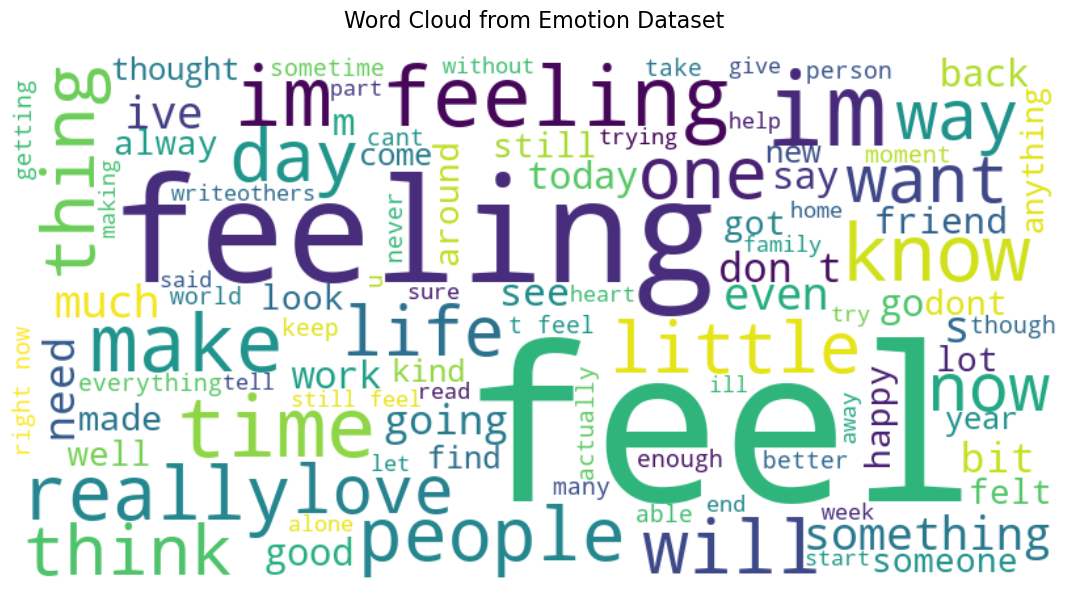

In [20]:
combined_text = ' '.join(train_df['text'].values)
print(f"Total characters: {len(combined_text)}")

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(combined_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from Emotion Dataset', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [21]:
from transformers import AutoTokenizer

model_ckpt = "microsoft/MiniLM-L12-H384-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

c:\Users\Pham Quoc Viet\.conda\envs\ds_env\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Pham Quoc Viet\.cache\huggingface\hub\models--microsoft--MiniLM-L12-H384-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [24]:
tokenizer(emotion_dataset['train']['text'][0])

{'input_ids': [101, 1045, 2134, 2102, 2514, 26608, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}

In [25]:
def tokenize(df):
    return tokenizer(df['text'], truncation=True, max_length=512)

emotion_dataset = emotion_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# Save the tokenized dataset to disk
save_path = "./tokenized_emotion_dataset"
emotion_dataset.save_to_disk(save_path)
print(f"Dataset saved to: {save_path}")

In [26]:
emotion_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [27]:
save_path = "./tokenized_emotion_dataset"
emotion_dataset.save_to_disk(save_path)
print(f"Dataset saved to: {save_path}")

Saving the dataset (0/1 shards):   0%|          | 0/16000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset saved to: ./tokenized_emotion_dataset
